# LinUCB — Reddit DSTC8 Corpus

LinUCB contextual bandit on the **Reddit DSTC8** customer service environment.
Reddit threads are longer (max 20 turns) with more neutral users.

### How LinUCB Works
- Uses **raw continuous features** directly (no discretization)
- Per-action ridge regression: `r ≈ θᵀx`
- UCB exploration: `action = argmax(θᵀx + α√(xᵀA⁻¹x))`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
import sys
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')
from environment import CustomerServiceEnv

print('all imports done!')

all imports done!


## Setting up the Environment

In [2]:
env = CustomerServiceEnv(dataset='reddit')

print(f'Environment: {env.dataset_name}')
print(f'Max turns per conversation: {env.max_turns}')
print(f'Initial sentiment: {env.initial_sentiment}')
print(f'Initial frustration: {env.initial_frustration}')
print(f'Available actions: {env.ACTIONS}')
print(f'State vector size: {env.get_state_size()}')

Environment: Reddit DSTC8 Corpus
Max turns per conversation: 20
Initial sentiment: 0.5
Initial frustration: 0.3
Available actions: ['ask_info', 'provide_solution', 'empathize', 'escalate', 'close']
State vector size: 4


## Running a random episode

In [3]:
state = env.reset()
total_reward = 0
print('--- Random Agent Episode ---')
print(f'Starting state: sentiment={state[0]:.2f}, frustration={state[1]:.2f}')
print()

while not env.done:
    action = random.randint(0, env.NUM_ACTIONS - 1)
    next_state, reward, done, outcome = env.step(action)
    total_reward += reward
    env.render(action)
    state = next_state

print(f'\nTotal reward: {total_reward:.2f}')
print(f'Conversation ended: {outcome}')

--- Random Agent Episode ---
Starting state: sentiment=0.54, frustration=0.37

  Turn  1 | Action: provide_solution
    Sentiment: 0.39 | Frustration: 0.57 | Info: 0.00
  Turn  2 | Action: provide_solution
    Sentiment: 0.19 | Frustration: 0.77 | Info: 0.00
  Turn  3 | Action: empathize
    Sentiment: 0.31 | Frustration: 0.67 | Info: 0.00
  Turn  4 | Action: close
    Sentiment: 0.31 | Frustration: 0.67 | Info: 0.00
    >> Outcome: abandoned

Total reward: -3.88
Conversation ended: abandoned


## LinUCB Agent

In [4]:
class LinUCBAgent:
    
    def __init__(self, n_actions=5, d=4, alpha=1.5):
        self.n_actions = n_actions
        self.d = d + 1  # +1 for info_gathered^2 feature expansion
        self.alpha = alpha
        self.A = [np.eye(self.d) for _ in range(n_actions)]
        self.b = [np.zeros(self.d) for _ in range(n_actions)]
        self.A_inv = [np.eye(self.d) for _ in range(n_actions)]

    def _get_features(self, state):
        """expand state with info_gathered^2 to help model the resolution threshold"""
        x = np.array(state, dtype=float)
        return np.append(x, x[2] ** 2)

    def choose_action(self, state):
        x = self._get_features(state)
        p_values = np.zeros(self.n_actions)
        for a in range(self.n_actions):
            theta = self.A_inv[a] @ self.b[a]
            ucb = self.alpha * np.sqrt(x @ self.A_inv[a] @ x)
            p_values[a] = theta @ x + ucb
        return np.argmax(p_values)
    
    def update(self, state, action, reward):
        x = self._get_features(state)
        # tanh normalization: squashes reward to (-1, 1) so large negatives
        # (e.g. -3 from escalation) don't catastrophically overwhelm b
        reward_norm = np.tanh(reward / 2.0)
        self.A[action] += np.outer(x, x)
        self.b[action] += reward_norm * x
        self.A_inv[action] = np.linalg.inv(self.A[action])

print('LinUCB agent defined (fixed)!')


LinUCB agent defined (fixed)!


## Training

In [5]:
agent = LinUCBAgent(n_actions=env.NUM_ACTIONS, d=env.get_state_size(), alpha=1.5)
num_episodes = 20000

all_rewards = []
all_outcomes = []
all_turns = []

for ep in range(num_episodes):
    state = env.reset()
    episode_reward = 0
    
    while not env.done:
        action = agent.choose_action(state)
        next_state, reward, done, outcome = env.step(action)
        agent.update(state, action, reward)
        episode_reward += reward
        state = next_state
    
    all_rewards.append(episode_reward)
    all_outcomes.append(outcome)
    all_turns.append(env.turn)
    
    if (ep + 1) % 4000 == 0:
        recent_rewards = all_rewards[-500:]
        recent_resolved = sum(1 for o in all_outcomes[-500:] if o == 'resolved') / 500
        recent_escalated = sum(1 for o in all_outcomes[-500:] if o == 'escalated') / 500
        print(f'Episode {ep+1}/{num_episodes}')
        print(f'  Avg reward (last 500): {np.mean(recent_rewards):.2f}')
        print(f'  Resolution rate: {recent_resolved:.1%}')
        print(f'  Escalation rate: {recent_escalated:.1%}')
        print(f'  Avg turns: {np.mean(all_turns[-500:]):.1f}')
        print()

print('Training complete!')

Episode 4000/20000
  Avg reward (last 500): 2.20
  Resolution rate: 19.6%
  Escalation rate: 0.0%
  Avg turns: 17.3

Episode 8000/20000
  Avg reward (last 500): 2.14
  Resolution rate: 17.8%
  Escalation rate: 0.0%
  Avg turns: 17.5

Episode 12000/20000
  Avg reward (last 500): 2.19
  Resolution rate: 19.8%
  Escalation rate: 0.0%
  Avg turns: 17.2

Episode 16000/20000
  Avg reward (last 500): 2.10
  Resolution rate: 17.4%
  Escalation rate: 0.0%
  Avg turns: 17.6

Episode 20000/20000
  Avg reward (last 500): 2.09
  Resolution rate: 16.0%
  Escalation rate: 0.0%
  Avg turns: 17.7

Training complete!


## Learning Curve

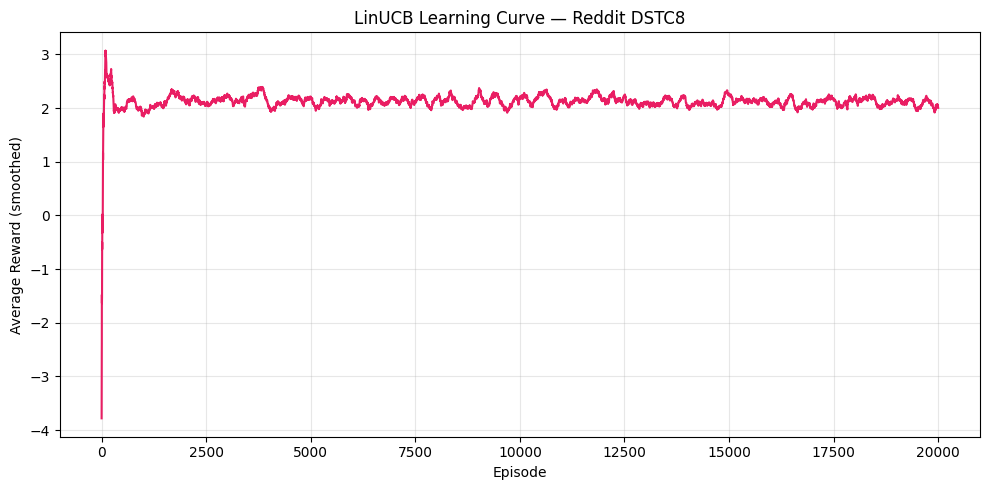

Starting avg reward (first 500): 2.16
Final avg reward (last 500): 2.09


In [6]:
window = 200
smoothed = [np.mean(all_rewards[max(0,i-window):i+1]) for i in range(len(all_rewards))]

plt.figure(figsize=(10, 5))
plt.plot(smoothed, color='#E91E63', linewidth=1.5)
plt.xlabel('Episode')
plt.ylabel('Average Reward (smoothed)')
plt.title('LinUCB Learning Curve — Reddit DSTC8')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Starting avg reward (first 500): {np.mean(all_rewards[:500]):.2f}')
print(f'Final avg reward (last 500): {np.mean(all_rewards[-500:]):.2f}')

## Resolution Rate Over Time

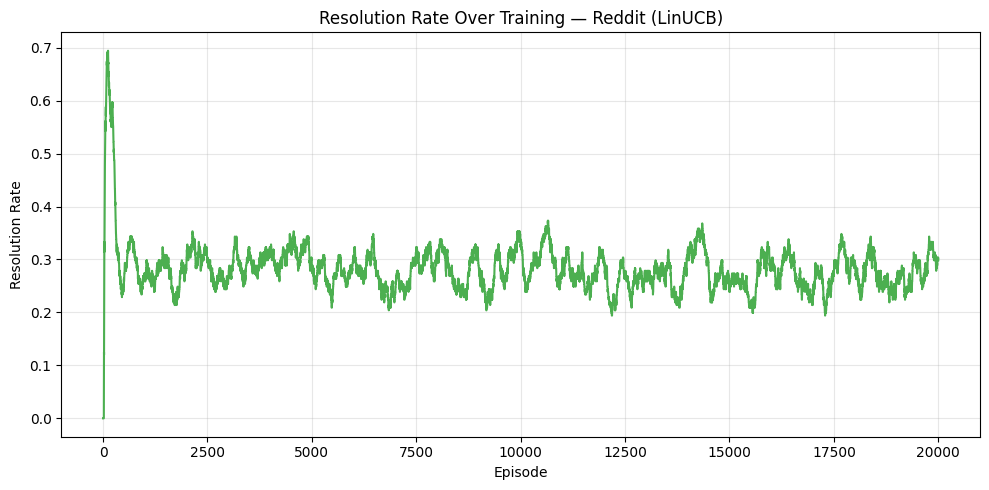

In [7]:
resolution_window = 200
resolution_rates = []
for i in range(len(all_outcomes)):
    start = max(0, i - resolution_window)
    window_outcomes = all_outcomes[start:i+1]
    rate = sum(1 for o in window_outcomes if o == 'resolved') / len(window_outcomes)
    resolution_rates.append(rate)

plt.figure(figsize=(10, 5))
plt.plot(resolution_rates, color='#4CAF50', linewidth=1.5)
plt.xlabel('Episode')
plt.ylabel('Resolution Rate')
plt.title('Resolution Rate Over Training — Reddit (LinUCB)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## What Actions did the Agent Learn?

In [7]:
test_scenarios = [
    {'name': 'Angry customer, no info', 'state': [0.2, 0.8, 0.1, 0.1]},
    {'name': 'Calm customer, no info', 'state': [0.7, 0.2, 0.1, 0.1]},
    {'name': 'Angry customer, lots of info', 'state': [0.2, 0.8, 0.8, 0.3]},
    {'name': 'Calm customer, lots of info', 'state': [0.7, 0.2, 0.8, 0.3]},
    {'name': 'Neutral, halfway through', 'state': [0.5, 0.5, 0.5, 0.5]},
]

print('What the agent would do in different situations:')
print('=' * 60)
for scenario in test_scenarios:
    state = np.array(scenario['state'])
    action = agent.choose_action(state)
    action_name = env.ACTIONS[action]
    print(f"\n{scenario['name']}:")
    print(f'  -> {action_name}')
    
    x = agent._get_features(state)
    for a in range(env.NUM_ACTIONS):
        theta = agent.A_inv[a] @ agent.b[a]
        ucb = agent.alpha * np.sqrt(x @ agent.A_inv[a] @ x)
        score = theta @ x + ucb
        bar = '#' * max(0, int(score * 5))
        print(f'     {env.ACTIONS[a]:18s} score={score:.3f} {bar}')


What the agent would do in different situations:

Angry customer, no info:
  -> ask_info
     ask_info           score=0.076 
     provide_solution   score=-0.387 
     empathize          score=-0.067 
     escalate           score=-0.096 
     close              score=-0.045 

Calm customer, no info:
  -> empathize
     ask_info           score=0.056 
     provide_solution   score=-0.180 
     empathize          score=0.114 
     escalate           score=-0.185 
     close              score=-0.047 

Angry customer, lots of info:
  -> provide_solution
     ask_info           score=0.148 
     provide_solution   score=1.257 ######
     empathize          score=0.033 
     escalate           score=-0.156 
     close              score=-0.006 

Calm customer, lots of info:
  -> provide_solution
     ask_info           score=0.177 
     provide_solution   score=1.508 #######
     empathize          score=0.229 #
     escalate           score=-0.027 
     close              score=0.151 

N

## Action Distribution Plot

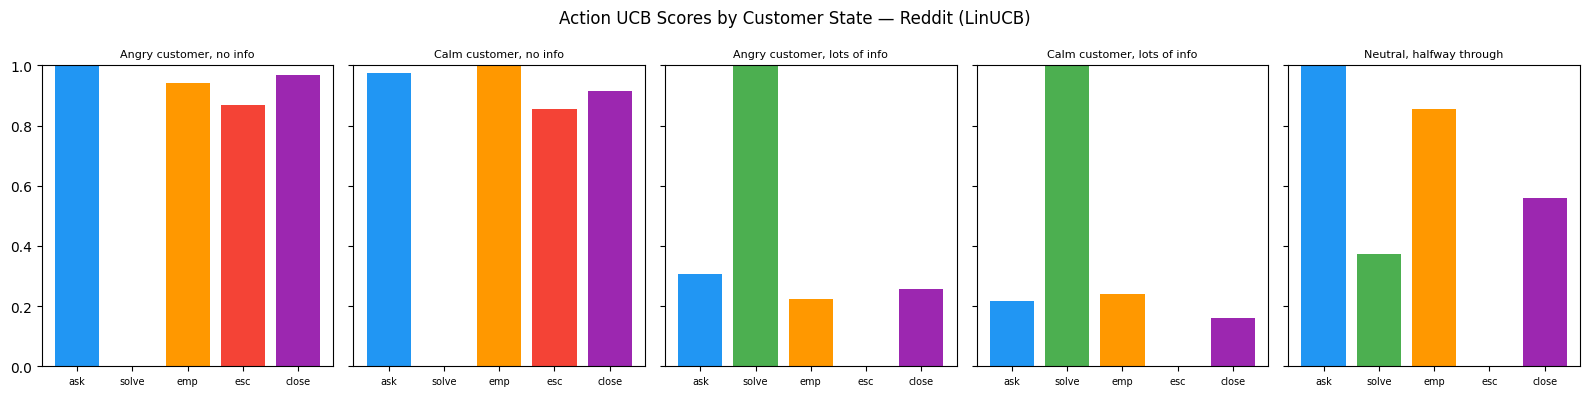

In [ ]:
fig, axes = plt.subplots(1, len(test_scenarios), figsize=(16, 4), sharey=True)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#f44336', '#9C27B0']

for idx, scenario in enumerate(test_scenarios):
    state = np.array(scenario['state'])
    x = agent._get_features(state)
    scores = np.zeros(env.NUM_ACTIONS)
    for a in range(env.NUM_ACTIONS):
        theta = agent.A_inv[a] @ agent.b[a]
        ucb = agent.alpha * np.sqrt(x @ agent.A_inv[a] @ x)
        scores[a] = theta @ x + ucb
    if scores.max() > scores.min():
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        scores_norm = np.ones(env.NUM_ACTIONS) / env.NUM_ACTIONS
    
    axes[idx].bar(range(env.NUM_ACTIONS), scores_norm, color=colors)
    axes[idx].set_title(scenario['name'], fontsize=8)
    axes[idx].set_xticks(range(env.NUM_ACTIONS))
    axes[idx].set_xticklabels(['ask', 'solve', 'emp', 'esc', 'close'], fontsize=7)
    axes[idx].set_ylim(0, 1)

fig.suptitle('Action UCB Scores by Customer State — Reddit (LinUCB Fixed)', fontsize=12)
plt.tight_layout()
plt.show()


## Testing the Trained Agent

In [8]:
print('='*60)
print('TESTING THE TRAINED AGENT — 3 sample conversations')
print('='*60)

for test_ep in range(3):
    state = env.reset()
    total_reward = 0
    print(f'\n--- Conversation {test_ep+1} ---')
    print(f'Customer arrives: sentiment={state[0]:.2f}, frustration={state[1]:.2f}')
    
    while not env.done:
        action = agent.choose_action(state)
        next_state, reward, done, outcome = env.step(action)
        total_reward += reward
        action_name = env.ACTIONS[action]
        print(f'  Turn {env.turn}: Agent chose [{action_name}] -> reward={reward:.2f}, sentiment={next_state[0]:.2f}, info={next_state[2]:.2f}')
        state = next_state
    
    print(f'  Result: {outcome} | Total reward: {total_reward:.2f} | Turns: {env.turn}')

TESTING THE TRAINED AGENT — 3 sample conversations

--- Conversation 1 ---
Customer arrives: sentiment=0.23, frustration=0.19
  Turn 1: Agent chose [empathize] -> reward=0.18, sentiment=0.35, info=0.00
  Turn 2: Agent chose [empathize] -> reward=0.18, sentiment=0.47, info=0.00
  Turn 3: Agent chose [empathize] -> reward=0.18, sentiment=0.59, info=0.00
  Turn 4: Agent chose [empathize] -> reward=0.18, sentiment=0.71, info=0.00
  Turn 5: Agent chose [empathize] -> reward=0.18, sentiment=0.83, info=0.00
  Turn 6: Agent chose [empathize] -> reward=0.18, sentiment=0.95, info=0.00
  Turn 7: Agent chose [empathize] -> reward=0.18, sentiment=1.00, info=0.00
  Turn 8: Agent chose [empathize] -> reward=0.18, sentiment=1.00, info=0.00
  Turn 9: Agent chose [empathize] -> reward=0.18, sentiment=1.00, info=0.00
  Turn 10: Agent chose [empathize] -> reward=0.18, sentiment=1.00, info=0.00
  Turn 11: Agent chose [empathize] -> reward=0.18, sentiment=1.00, info=0.00
  Turn 12: Agent chose [empathize] -

## Final Summary Stats

In [9]:
test_rewards = []
test_outcomes = {'resolved': 0, 'escalated': 0, 'abandoned': 0}
test_turns = []

for _ in range(500):
    state = env.reset()
    ep_reward = 0
    while not env.done:
        action = agent.choose_action(state)
        state, reward, done, outcome = env.step(action)
        ep_reward += reward
    test_rewards.append(ep_reward)
    test_outcomes[outcome] += 1
    test_turns.append(env.turn)

print('='*50)
print('FINAL EVALUATION (500 test episodes)')
print('='*50)
print(f'Average reward:     {np.mean(test_rewards):.2f}')
print(f'Resolution rate:    {test_outcomes["resolved"]/500:.1%}')
print(f'Escalation rate:    {test_outcomes["escalated"]/500:.1%}')
print(f'Abandonment rate:   {test_outcomes["abandoned"]/500:.1%}')
print(f'Avg conversation:   {np.mean(test_turns):.1f} turns')
print('='*50)

FINAL EVALUATION (500 test episodes)
Average reward:     2.13
Resolution rate:    18.0%
Escalation rate:    0.0%
Abandonment rate:   82.0%
Avg conversation:   17.5 turns


## Observations

*TODO: Write your observations here after running the notebook.*